# ¿Se desintegra el protón?

### Boletín guiado (versión simple): el límite de Super-Kamiokande a $p \to e^+ + \pi^0$

Jose A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

In [1]:
# Configuración e imports
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as units
from scipy.stats import poisson, binom

import sys; sys.path.append('..')   # fnyp está en notebooks/

try:
    from fnyp import common as fn
except ModuleNotFoundError:      # en Google Colab hay que traerse antes el repositorio
    !git clone -q https://github.com/jahernando/USC-FNyP.git
    import sys; sys.path.append('USC-FNyP/notebooks')
    from fnyp import common as fn

fn.version()

 Last version  Thu Sep 17 14:26:35 2026


## Objetivos

* Leer el *abstract* de un artículo de búsqueda y extraer los números relevantes.

* Identificar los **blancos** y contarlos: los protones de Super-Kamiokande (SK).

* Entender la **exposición**: $N_0$ protones durante $T$ años equivalen a $T N_0$ protones durante un año.

* Estimar el número de desintegraciones esperadas cuando $\tau \gg t$.

* Entender que, con pocos sucesos, el número observado sigue una **distribución de Poisson**.

* Si no se observa nada, fijar un **límite al 90% de nivel de confianza** (CL) y comprobar qué significa con experimentos simulados.

* Ver que con **fondo** las cosas se complican.

## El problema

En el Modelo Estándar el número bariónico $B$ se conserva, esto implica que el protón no se desintegra, es el barión más ligero.

Las teorías de Gran Unificación (GUT) sitúan quarks y leptones en los mismos multipletes, y predicen que el protón se desintegra, esto es violan la conservación del número bariónico, con vidas medias del orden de $10^{34}$–$10^{36}$ años.

El canal favorito de muchas GUT es:

$$
p \to e^+ + \pi^0
$$

SK no mide la vida media total del protón $\tau$, sino la **vida media parcial** $\tau/\mathcal{B}$ del canal que busca,
donde $\mathcal{B}$ es su fracción de desintegración.

## Super-Kamiokande

| |
| :--: |
| <img src="../imgs/leptons_SK.png" width = 460 align = "center"> |
| Super-Kamiokande a) dibujo del detector b) principio de detección [SK, MT13.2] |

Tanque cilíndrico de agua ultrapura: 50 kt, 11 k PMTs, a 1000 m bajo la montaña Ikenoyama (Japón).

Toma datos desde 1996. Su sucesor, Hyper-Kamiokande (HK), 260 kt, con participación de la USC.

## El artículo

Super-Kamiokande Collaboration, *Search for proton decay via $p\to e^+\pi^0$ and $p\to \mu^+\pi^0$
with an enlarged fiducial volume in Super-Kamiokande I-IV*,
Phys. Rev. D 102, 112011 (2020), [arXiv:2010.16098](https://arxiv.org/abs/2010.16098)

> We have searched for proton decay via $p\to e^+\pi^0$ and $p\to \mu^+\pi^0$ modes with the enlarged fiducial volume data of
> Super-Kamiokande from April 1996 to May 2018, which corresponds to 450 kton$\cdot$years exposure.
> We have accumulated about 25% more livetime and enlarged the fiducial volume of the Super-Kamiokande detector
> from 22.5 kton to 27.2 kton for this analysis, so that 144 kton$\cdot$years of data, including
> 78 kton$\cdot$years of additional fiducial volume data, has been newly analyzed.
> No candidates have been found for $p\to e^+\pi^0$ and one candidate remains for $p\to \mu^+\pi^0$
> in the conventional 22.5 kton fiducial volume and it is consistent with the atmospheric neutrino background prediction.
> We set lower limits on the partial lifetime for each of these modes:
> $\tau/Br(p\to e^+\pi^0) > 2.4 \times 10^{34}$ years and $\tau/Br(p\to \mu^+\pi^0) > 1.6 \times 10^{34}$ years
> at 90% confidence level.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Leer un *abstract*</b></p>

Lee **solo** el *abstract* y responde:

1. ¿Qué canales se buscan? ¿Cuántos años de datos?
2. ¿Qué es la **exposición**? ¿Por qué se da en kt·año y no en años?
3. ¿Qué es el **volumen fiducial**? ¿Por qué es menor que los 50 kt del tanque?
4. ¿Qué resultado se da? ¿Es una medida o un límite?
5. ¿Cómo se compara $2.4 \times 10^{34}$ años con la edad del Universo, $1.38 \times 10^{10}$ años?

</div>

<details>
<summary><b>Solución</b></summary>

1. $p\to e^+\pi^0$ y $p\to\mu^+\pi^0$. Datos de abril 1996 a mayo 2018: 22 años de calendario (con paradas).
2. Exposición = masa × tiempo de toma de datos. Lo que cuenta es el número de **protones·año** observados:
   10 kt durante 1 año equivalen a 1 kt durante 10 años.
3. Volumen interior, alejado de las paredes, donde se aceptan los sucesos. Cerca de las paredes la reconstrucción
   es peor y entra más fondo (radiactividad de la roca y de los PMTs, muones cósmicos). Es un compromiso
   entre masa y limpieza: la novedad del artículo es ampliarlo de 22.5 a 27.2 kt.
4. No hay señal: un **límite inferior** a la vida media parcial al 90% CL.
5. $2.4 \times 10^{34} / 1.38 \times 10^{10} \approx 1.7 \times 10^{24}$ veces la edad del Universo.
   ¡Y aun así se puede medir! El truco: muchísimos protones.

</details>

In [2]:
tau_lim = 2.4e34     # años, tau/Br(p -> e+ pi0) al 90% CL [SK 2020]
t_U     = 1.38e10    # años, edad del Universo

print('tau/Br / edad del Universo = {:.1e}'.format(tau_lim / t_U))

tau/Br / edad del Universo = 1.7e+24


## Los blancos

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Los blancos</b></p>

En una búsqueda de desintegraciones, los **blancos** son las partículas que podrían desintegrarse.

Masa molar del agua $M_A = 18.015$ g/mol; $N_A = 6.022 \times 10^{23}$ mol$^{-1}$.

1. ¿Cuáles son los blancos en SK?
2. ¿Cuántos hay en 1 kt de agua? ¿Y en el volumen fiducial de 22.5 kt?

</div>

In [3]:
N_A = units.N_A      # 1/mol
M_A = 18.015         # g/mol, agua
kt  = 1e9            # g

n_mol   = kt / M_A * N_A     # moléculas de H2O por kt
p_total = 10 * n_mol         # protones por kt: 2 del H y 8 del O
N0      = 22.5 * p_total     # protones en el volumen fiducial

print('moléculas / kt       = {:.2e}'.format(n_mol))
print('protones / kt        = {:.2e}'.format(p_total))
print('protones en 22.5 kt  = {:.2e}'.format(N0))

moléculas / kt       = 3.34e+31
protones / kt        = 3.34e+32
protones en 22.5 kt  = 7.52e+33


<details>
<summary><b>Solución</b></summary>

1. Los protones del agua: 2 libres (H) y 8 ligados en el $^{16}$O por molécula. SK usa los 10.
2. $3.34 \times 10^{31}$ moléculas y $3.34 \times 10^{32}$ protones por kt. En 22.5 kt, $N_0 = 7.52 \times 10^{33}$ protones.

</details>

## La exposición

SK resume sus datos en una **exposición** de 450 kt·año.

Para vidas medias muy largas ($\tau \gg t$), observar $N_0$ protones durante $T$ años es lo mismo que observar
$T\,N_0$ protones durante un año: solo importa el producto $N_0\,T$, la exposición.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — La exposición</b></p>

Si todos los datos se hubieran tomado con el volumen fiducial de 22.5 kt, ¿cuántos años de toma de datos serían? ¿Y con 1 kt?

</div>

In [4]:
exposicion = 450 * p_total            # protones x año

print('años con 22.5 kt = {:.0f}'.format(450 / 22.5))
print('años con 1 kt    = {:.0f}'.format(450 / 1))
print('exposición       = {:.2e} protones año'.format(exposicion))

años con 22.5 kt = 20
años con 1 kt    = 450
exposición       = 1.50e+35 protones año


<details>
<summary><b>Solución</b></summary>

$450/22.5 = 20$ años. Con 1 kt, 450 años. (En realidad, SK combina periodos con 22.5 y 27.2 kt.)

En protones: $450 \times 3.34 \times 10^{32} = 1.50 \times 10^{35}$ protones·año.

</details>

## ¿Cuántas desintegraciones esperamos?

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Desintegraciones esperadas</b></p>

Supón que $\tau/\mathcal{B}$ es justo el límite de SK, $2.4 \times 10^{34}$ años.
La eficiencia de selección de SK (fracción de desintegraciones que detecta) es $\varepsilon = 0.37$.

1. Con $N_0$ protones, ¿cuántos quedan tras un tiempo $t$? Demuestra que, si $t \ll \tau$, el número medio de desintegraciones es $N_0\,t/\tau$.
2. ¿Cuántas desintegraciones esperas detectar en **un año** en el volumen fiducial de 22.5 kt? ¿Y con la exposición de 450 kt·año?
3. ¿Qué masa de agua necesitas para detectar, en promedio, **una** desintegración al año?

</div>

In [5]:
eps = 0.37                    # eficiencia de SK para p -> e+ pi0
tau = tau_lim                 # años

print('nu en 1 año (22.5 kt)       = {:.2f}'.format(eps * N0 * 1 / tau))
print('nu con 450 kt año           = {:.2f}'.format(eps * exposicion / tau))
print('masa para nu = 1 al año     = {:.0f} kt'.format(tau / (eps * p_total)))

nu en 1 año (22.5 kt)       = 0.12
nu con 450 kt año           = 2.32
masa para nu = 1 al año     = 194 kt


<details>
<summary><b>Solución</b></summary>

1. $N(t) = N_0\,e^{-t/\tau} \simeq N_0\,(1 - t/\tau)$, luego se desintegran $N_0 - N(t) \simeq N_0\,t/\tau$.
2. SK detecta, en promedio, $\nu = \varepsilon N_0\,t/\tau$: $\nu = 0.12$ en un año. Con la exposición total, $\nu = 2.3$.
   SK no ha visto ninguna: lo veremos en el Taller *No vemos nada*.
3. $\approx 190$ kt, como el volumen fiducial de Hyper-Kamiokande (187 kt).

</details>

## La distribución de Poisson

Cada protón es un "intento" con una probabilidad minúscula de desintegrarse en el tiempo $t$:

$$
p = \frac{t}{\tau} \sim 10^{-34}
$$

El número de desintegraciones entre $N_0 \sim 10^{34}$ protones sigue una **binomial** $B(n \,|\, N_0, p)$.

Cuando $N_0 \to \infty$, $p \to 0$ con $\nu = N_0 p$ fijo, la binomial tiende a la **Poisson**:

$$
P(n \,|\, \nu) = \frac{\nu^n}{n!} \, e^{-\nu}, \qquad \langle n \rangle = \nu, \qquad \sigma_n = \sqrt{\nu}
$$

Solo depende de $\nu$: da igual cuántos protones y cuánto tiempo, solo importa el número medio.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Pocos sucesos</b></p>

1. Demuestra que, si $N_0 \to \infty$ y $p \to 0$ con $\nu = N_0 p$ fijo, la binomial tiende a la Poisson.
2. Simula el número de desintegraciones detectadas en 10000 "años" de SK (22.5 kt) para $\tau/\mathcal{B} = 2.4 \times 10^{34}$ años
   y para $\tau/\mathcal{B} = 2.8 \times 10^{32}$ años. Compara los histogramas con la Poisson.
   ¿Cuál es el resultado más probable en cada caso? ¿Con qué probabilidad no se ve nada?

</div>

nu =  0.12: más probable n = 0, P(0) = 0.89, P(1) = 0.1
nu =  9.94: más probable n = 9, P(0) = 4.8e-05, P(1) = 0.00048


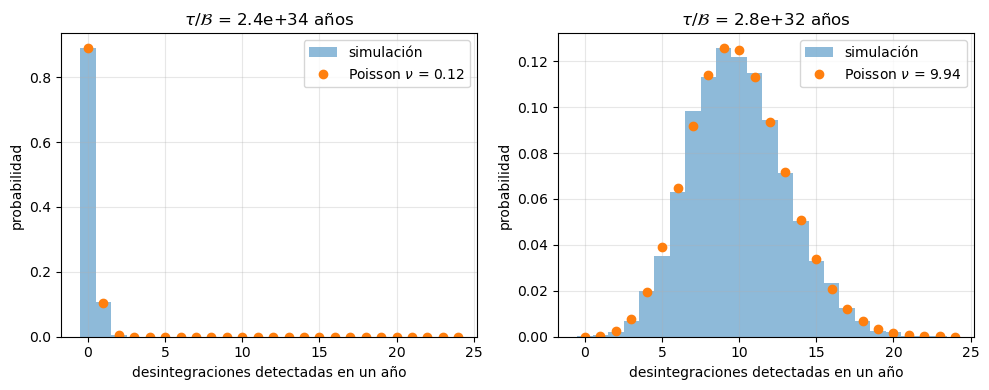

In [6]:
rng    = np.random.default_rng()
n_años = 10000

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
for ax, tau_i in zip(axs, (2.4e34, 2.8e32)):
    nu_i    = eps * N0 * 1 / tau_i
    cuentas = rng.poisson(nu_i, size=n_años)       # un número por cada 'año' simulado
    ns = np.arange(0, 25)
    ax.hist(cuentas, bins=ns - 0.5, density=True, alpha=0.5, label='simulación')
    ax.plot(ns, poisson.pmf(ns, nu_i), 'o', label=r'Poisson $\nu$ = {:.2f}'.format(nu_i))
    ax.set_xlabel('desintegraciones detectadas en un año'); ax.set_ylabel('probabilidad')
    ax.set_title(r'$\tau/\mathcal{{B}}$ = {:.1e} años'.format(tau_i))
    ax.grid(alpha=0.3); ax.legend()
    print('nu = {:5.2f}: más probable n = {}, P(0) = {:.2g}, P(1) = {:.2g}'.format(
          nu_i, ns[np.argmax(poisson.pmf(ns, nu_i))], poisson.pmf(0, nu_i), poisson.pmf(1, nu_i)))
fig.tight_layout()

<details>
<summary><b>Solución</b></summary>

1. Con $p = \nu/N_0$:

$$
B(n \,|\, N_0, p) = \frac{\nu^n}{n!} \, \underbrace{\frac{N_0 (N_0-1) \cdots (N_0-n+1)}{N_0^n}}_{\to 1} \,
\underbrace{\left(1 - \frac{\nu}{N_0}\right)^{N_0}}_{\to e^{-\nu}} \,
\underbrace{\left(1 - \frac{\nu}{N_0}\right)^{-n}}_{\to 1}
\longrightarrow \frac{\nu^n}{n!} e^{-\nu}
$$

   Con $\sim 10^{34}$ protones la Poisson es exacta a efectos prácticos.

2. $\nu = 0.12$ y $\nu = 10$ al año. Con $\nu = 0.12$ lo más probable es **no ver nada**: $P(0) = 89\%$, $P(1) = 10\%$.
   Con $\nu = 10$ lo más probable es ver 9 o 10 y $P(0) = e^{-10} \approx 5 \times 10^{-5}$; la distribución es casi gaussiana, con $\sigma = \sqrt{10} \approx 3.2$.

</details>

## No vemos nada: ¿qué podemos decir?

SK no observa ninguna desintegración $p \to e^+ + \pi^0$ ($n = 0$), con una exposición de 450 kt·año y sin fondo.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — No vemos nada</b></p>

1. Calcula $P(0 \,|\, \nu)$ para $\nu = 0.1, \, 1, \, 2.3, \, 5$. ¿Hay algún valor de $\nu$ que sea imposible? ¿Podemos medir $\tau/\mathcal{B}$? ¿Qué necesitamos para decir algo?
2. Con el criterio del 90% CL (ver la **Ayuda** al final), ¿qué valores de $\nu$ quedan excluidos? ¿Qué límite pones a $\tau/\mathcal{B}$? Compáralo con el de SK.
3. ¿Qué límite habrías obtenido olvidando la eficiencia ($\varepsilon = 1$)? ¿Por qué no es correcto?

</div>

P(0 | nu = 0.1) = 0.905
P(0 | nu =   1) = 0.368
P(0 | nu = 2.3) = 0.100
P(0 | nu =   5) = 0.007

nu_90                  = 2.30
límite con eps = 0.37  = 2.4e+34 años
límite con eps = 1     = 6.5e+34 años


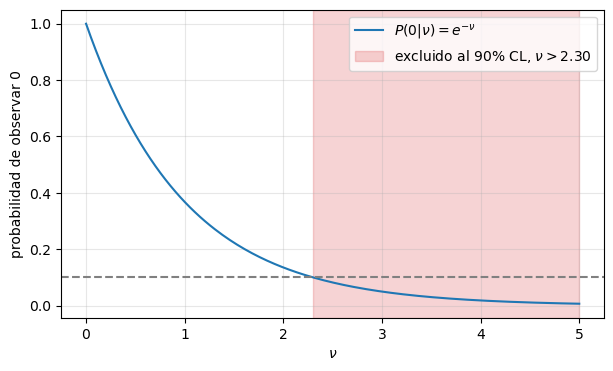

In [7]:
for nu_i in (0.1, 1, 2.3, 5):
    print('P(0 | nu = {:3}) = {:.3f}'.format(nu_i, poisson.pmf(0, nu_i)))

nu90 = -np.log(0.10)                  # n = 0: nu > 2.30 excluido al 90% CL
print()
print('nu_90                  = {:.2f}'.format(nu90))
print('límite con eps = {:.2f}  = {:.1e} años'.format(eps, eps * exposicion / nu90))
print('límite con eps = 1     = {:.1e} años'.format(exposicion / nu90))

nus = np.linspace(0, 5, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nus, poisson.pmf(0, nus), label=r'$P(0 | \nu) = e^{-\nu}$')
ax.axhline(0.10, color='gray', ls='--')
ax.axvspan(nu90, 5, color='C3', alpha=0.2, label=r'excluido al 90% CL, $\nu > {:.2f}$'.format(nu90))
ax.set_xlabel(r'$\nu$'); ax.set_ylabel('probabilidad de observar 0')
ax.grid(alpha=0.3); ax.legend();

<details>
<summary><b>Solución</b></summary>

1. $P(0 \,|\, \nu) = e^{-\nu}$: 0.90, 0.37, 0.10 y 0.007. Ningún $\nu$ es imposible, solo cada vez más improbable:
   con un único resultado $n = 0$ no se puede medir $\nu$. Hace falta un **criterio** para decidir a partir de qué
   probabilidad descartamos un valor, y decirlo junto al resultado: el nivel de confianza.

2. Se excluye $\nu$ si $e^{-\nu} < 0.10$, es decir, $\nu > \ln 10 = 2.30$. Como $\nu = \varepsilon N_0 t/\tau$:

$$
\frac{\tau}{\mathcal{B}} > \frac{\varepsilon \, N_0 \, t}{2.30} = \frac{0.37 \times 1.50 \times 10^{35}}{2.30} = 2.4 \times 10^{34} \text{ años} \qquad (90\%\ \mathrm{CL})
$$

   el límite de SK. Por eso, con $\tau/\mathcal{B}$ justo en el límite, esperábamos $\nu = 2.3$: es el valor frontera.

3. $\tau/\mathcal{B} > 6.5 \times 10^{34}$ años: un límite casi tres veces más fuerte, pero falso. SK solo detecta el 37%
   de las desintegraciones (se pierde señal en los cortes que rechazan el fondo de neutrinos atmosféricos y por la absorción
   o dispersión del $\pi^0$ en el oxígeno): con $\varepsilon = 1$ supondríamos una sensibilidad que no tiene.

</details>

## ¿Qué significa el 90%? Experimentos simulados

Hay que distinguir dos números:

* $\nu$: el número **esperado** de desintegraciones detectadas. Lo fijan la física ($\tau/\mathcal{B}$) y el experimento ($\varepsilon N_0 t$).

* $n$: el número **observado** en un experimento concreto. Es entero y aleatorio, y sigue una Poisson de media $\nu$.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — Experimentos que no ven nada</b></p>

Usa la exposición y la eficiencia de SK.

Para 30 valores de $\tau/\mathcal{B}$ entre $10^{33.5}$ y $10^{35.5}$ años, genera 10000 experimentos como SK y dibuja
la fracción de experimentos que no ven nada ($n = 0$) frente a $\tau/\mathcal{B}$.

¿Qué fracción de experimentos no ve nada si $\tau/\mathcal{B} = 2.4 \times 10^{34}$ años? ¿Dónde cruza la curva el 10%?
¿Qué valores de $\tau/\mathcal{B}$ excluye SK?

</div>

tau/B = 2.4e+34 años: n = 0 en el 10.2% de los experimentos


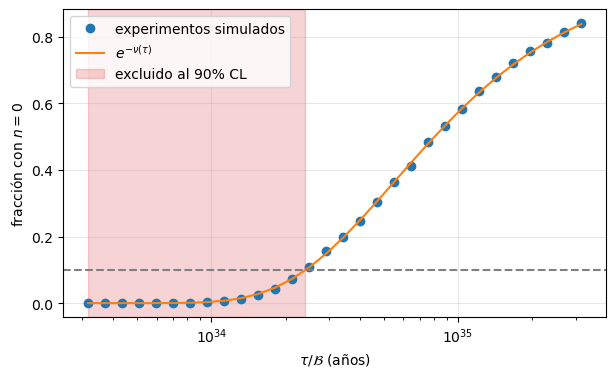

In [8]:
n_exp = 10000
taus  = np.logspace(33.5, 35.5, 30)                      # años

frac0 = [np.mean(rng.poisson(eps * exposicion / tau_i, size=n_exp) == 0) for tau_i in taus]
f_lim = np.mean(rng.poisson(eps * exposicion / tau_lim, size=n_exp) == 0)
print('tau/B = {:.1e} años: n = 0 en el {:.1f}% de los experimentos'.format(tau_lim, 100 * f_lim))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(taus, frac0, 'o', label='experimentos simulados')
ax.plot(taus, np.exp(-eps * exposicion / taus), label=r'$e^{-\nu(\tau)}$')
ax.axhline(0.10, color='gray', ls='--')
ax.axvspan(taus[0], tau_lim, color='C3', alpha=0.2, label='excluido al 90% CL')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau/\mathcal{B}$ (años)'); ax.set_ylabel('fracción con $n = 0$')
ax.grid(alpha=0.3); ax.legend();

<details>
<summary><b>Solución</b></summary>

Con $\nu = 0.37 \times 1.50 \times 10^{35}/(\tau/\mathcal{B})$, la fracción con $n = 0$ sigue $e^{-\nu}$ y crece con $\tau/\mathcal{B}$.

Para $\tau/\mathcal{B} = 2.4 \times 10^{34}$ años, $\nu = 2.3$ y la fracción es $e^{-2.3} \approx 10\%$ (la simulación lo
reproduce dentro de su fluctuación estadística, $\sqrt{P(1-P)/10000} \approx 0.3\%$): la curva cruza el 10% justo en el límite de SK.

Para valores menores, menos del 10% de los experimentos vería $n = 0$: están **excluidos** al 90% CL. Para valores mayores,
ver $n = 0$ es lo normal: SK no puede decir nada de ellos.

Que $\tau/\mathcal{B}$ esté justo en el límite no significa que no pueda ser el verdadero: en ese caso, el 10% de los experimentos no vería nada.

</details>

## ¿Y si hay fondo?

Algunas interacciones de neutrinos atmosféricos imitan la señal.

Si se esperan $b$ sucesos de **fondo** y $\nu_s$ de señal, el criterio de la Ayuda se generaliza a: $\nu_s$ está excluido al 90% CL si

$$
P(n \leq n_{obs} \,|\, \nu_s + b) < 0.10
$$

<div class="admonition tip">
<p class="admonition-title"><b>[>] Taller — El límite con fondo</b></p>

1. Si $n_{obs} = 0$ y $b = 3$, ¿qué límite obtienes para $\nu_s$? ¿Tiene sentido?
2. En $p \to \mu^+ + \pi^0$ SK observa un candidato, con $b \approx 0.94$. ¿Por qué su límite es peor ($1.6$ frente a $2.4 \times 10^{34}$ años)?

</div>

In [9]:
from scipy.optimize import brentq

def nu_s_90(n_obs, b, cl=0.90):
    # Límite superior clásico en la señal: P(n <= n_obs | s + b) = 1 - cl
    f = lambda s: poisson.cdf(n_obs, s + b) - (1 - cl)
    return brentq(f, -b, 50)       # f(-b) = 0.9 > 0 y f(50) < 0

print('n_obs = 0, b = 3    : nu_s_90 = {:.2f}'.format(nu_s_90(0, 3)))
print('n_obs = 1, b = 0.94 : nu_s_90 = {:.2f}, factor frente a n_obs = 0, b = 0: {:.2f}'.format(
      nu_s_90(1, 0.94), nu_s_90(1, 0.94) / nu_s_90(0, 0)))

n_obs = 0, b = 3    : nu_s_90 = -0.70
n_obs = 1, b = 0.94 : nu_s_90 = 2.95, factor frente a n_obs = 0, b = 0: 1.28


<details>
<summary><b>Solución</b></summary>

1. $e^{-(\nu_s + 3)} < 0.10 \Rightarrow \nu_s > 2.30 - 3 = -0.70$: se excluye cualquier señal, ¡incluso $\nu_s = 0$! Es absurdo,
   y además premia a un experimento con mucho fondo que ha tenido la "suerte" de ver menos sucesos de los esperados.
   Con fondo hace falta un método más cuidadoso: [Feldman y Cousins](https://arxiv.org/abs/physics/9711021) (1998) dan
   $\nu_s \in [0, 1.08]$ en este caso. SK usa un método bayesiano.

2. Con un candidato hay que admitir más señal: $P(n \leq 1 \,|\, \nu_s + 0.94) = 0.10$ da $\nu_s < 2.95$, frente a $2.30$ con
   $n_{obs} = 0$, y el límite en $\tau/\mathcal{B}$ es un factor $\approx 1.3$ peor. La eficiencia de $\mu^+ + \pi^0$, algo menor,
   y los detalles del análisis de SK explican el resto.

</details>

## Ayuda: el límite al 90% CL

Un valor de $\nu$ queda **excluido al 90% CL** si, siendo cierto, la probabilidad de obtener un resultado como el observado
**o más extremo** (aquí, menos sucesos) es menor del 10%.

Es decir, si ese $\nu$ fuera el verdadero, **más del 90% de los experimentos observarían más sucesos** que los que hemos visto.

*Ojo*: no significa que haya un 90% de probabilidad de que ese $\nu$ sea falso.

## Resumen

* Los **blancos** de SK son los protones del agua: $3.34 \times 10^{32}$ por kt, $7.5 \times 10^{33}$ en el volumen fiducial de 22.5 kt.

* Para $\tau \gg t$ solo importa la **exposición** $N_0\,t$: SK acumula 450 kt·año $= 1.5 \times 10^{35}$ protones·año.

* El número medio de desintegraciones detectadas es $\nu = \varepsilon N_0 t/\tau$: con $\tau/\mathcal{B} \sim 10^{34}$ años, $\lesssim 1$ al año en SK.

* El número observado sigue una **Poisson** de media $\nu$: con $\nu$ pequeño, lo más probable es no ver nada.

* Si no se observa nada, $\nu < 2.30$ al 90% CL y $\tau/\mathcal{B} > \varepsilon N_0 t/2.30$: con $\varepsilon = 0.37$, el límite de SK, $2.4 \times 10^{34}$ años.

* Si $\tau/\mathcal{B}$ estuviera en el límite, el 10% de los experimentos como SK no vería nada.

* Con **fondo**, el método simple da resultados sin sentido: Feldman-Cousins o métodos bayesianos.

* El límite crece con la exposición: de ahí Hyper-Kamiokande.

## Bibliografía

* [SK2020] Super-Kamiokande Collaboration, Phys. Rev. D 102, 112011 (2020), [arXiv:2010.16098](https://arxiv.org/abs/2010.16098)

* [FC] G. J. Feldman, R. D. Cousins, Phys. Rev. D 57, 3873 (1998), [arXiv:physics/9711021](https://arxiv.org/abs/physics/9711021)

* [PDG] Particle Data Group, *Statistics* y *Grand Unified Theories*, [pdg.lbl.gov](https://pdg.lbl.gov/)

* [AB] A. Bettini, *Introduction to Elementary Particle Physics*, Cambridge U. Press.

* [MT] M. Thomson, *Modern Particle Physics*, Cambridge U. Press.